# Portfolio backtest — 4 pairs (ETH · LINK · SOL · XRP)

Runs the **tail-6000-row** holdout for each pair independently using that pair's own:
- `artifacts/scalers.pkl` — scalers fitted on the training slice
- Conv1D / LSTM / Hybrid `.pt` checkpoints — top-2 per architecture
- Per-pair `SL_POINTS`, `TP_POINTS`, `THRESHOLD` that were tuned on the selection window

**No cross-pair signal mixing**: each pair's entry/exit decision is computed exactly as it
would be in that pair's standalone `backtest/main.ipynb`. The portfolio is assembled only
after every pair has produced its own independent equity curve.

### Feature engineering (same as every CNN_* backtest notebook)
8 ratio/volume features, `seq_len = 48`, `MaxAbsScaler` per feature fitted on the train slice.

### Individual vs portfolio simulation
- **Per pair**: fixed notional `pos_size = 1000` (same as single-pair `backtest/main.ipynb`).
- **Portfolio (one pool)**: initial total = `PORTFOLIO_INITIAL` (default **1000**). When a leg opens a trade, notional = **current portfolio equity ÷ 4**, so gains/losses compound and each leg always risks a quarter of the **current** account.
- **CSV**: After the run, `PORTFOLIO_BARS_CSV` (`portfolio_bars_timeseries.csv`) stores **one row per bar** in time order: equity, cash, unrealized, slice, per-leg `mean_signal`, `desired`, `pos`, `notional`, `entry_price`, and OHLC.



In [36]:
import os
import re
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MaxAbsScaler

import torch
import torch.nn as nn


def set_all_seeds(seed: int = 0):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)


set_all_seeds(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [37]:
# ============================================================
# CONFIG
# ============================================================

ROOT = Path(r"C:\Users\jtoma\projects\NN")

# Tail window: last N rows of each CSV are used for evaluation.
TAIL_ROWS = 6000

# Sequence length — must match what each pair was trained with.
SEQ_LEN = 48

# Top-k checkpoints per architecture per pair.
K_CHECKPOINTS = 2

# Shared-pool portfolio: one initial capital; each leg uses (equity / 4) as notional
# when opening a trade (compounding / rebalancing).
PORTFOLIO_INITIAL = 1000.0

# CSV: série temporal bar-a-bar do portfolio (equity, posições, sinais, OHLC por par)
PORTFOLIO_BARS_CSV = ROOT / "PORTFOLIO" / "backtest_4pairs" / "portfolio_bars_timeseries.csv"

# Per-pair configuration.
# sl_points / tp_points: USD distance from entry price (same units as OHLC).
# threshold: minimum |mean_signal| to open a position.
# These values come directly from each pair's tuned BEST_SL / BEST_TP / THRESHOLD.
PAIRS = [
    {
        "name": "ETH",
        "root": ROOT / "CNN_ETH",
        "data": ROOT / "CNN_ETH" / "data" / "ETHUSDT-1h-data.csv",
        "sl_points": 3.0,
        "tp_points": 50.0,
        "threshold": 0.0007,
        "pos_size": 1000.0,
    },
    {
        "name": "LINK",
        "root": ROOT / "CNN_LINK",
        "data": ROOT / "CNN_LINK" / "data" / "LINKUSDT-1h-data.csv",
        "sl_points": 0.02,
        "tp_points": 0.45,
        "threshold": 0.0007,
        "pos_size": 1000.0,
    },
    {
        "name": "SOL",
        "root": ROOT / "CNN_SOL",
        "data": ROOT / "CNN_SOL" / "data" / "SOLUSDT-1h-data.csv",
        "sl_points": 0.3,
        "tp_points": 3.0,
        "threshold": 0.0007,
        "pos_size": 1000.0,
    },
    {
        "name": "XRP",
        "root": ROOT / "CNN_XRP",
        "data": ROOT / "CNN_XRP" / "data" / "XRPUSDT-1h-data.csv",
        "sl_points": 0.0005,
        "tp_points": 0.07,
        "threshold": 0.0005,
        "pos_size": 1000.0,
    },
]



In [38]:
# ============================================================
# FEATURE ENGINEERING & PREPROCESSING
# (identical to every CNN_* backtest/main.ipynb)
# ============================================================

def build_features(opens, highs, lows, closes, volumes, train_scalers=None):
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    features = [feature1, feature2, feature3, feature4, feature5, feature6, feature7, feature8]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        scaler = train_scalers[i]
        if is_train:
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
        else:
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))
        scaled_fts.append(scaled_ft.flatten())

    scaled_features = np.stack(scaled_fts, axis=-1)
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers


def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)
    opens   = np.array(df["open"].values,   dtype=float)
    highs   = np.array(df["high"].values,   dtype=float)
    lows    = np.array(df["low"].values,    dtype=float)
    closes  = np.array(df["close"].values,  dtype=float)
    volumes = np.array(df["volume"].values, dtype=float)

    features, num_features, train_scalers = build_features(
        opens, highs, lows, closes, volumes, train_scalers
    )

    num_samples = m - seq_len
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    for i in range(num_samples):
        X[i] = features[i : i + seq_len]
        Y[i] = features[i + seq_len : i + seq_len + 1]

    opens  = np.array(opens[seq_len:])
    highs  = np.array(highs[seq_len:])
    lows   = np.array(lows[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, highs, lows, closes, train_scalers


In [39]:
# ============================================================
# MODEL ARCHITECTURES
# (identical to every CNN_* backtest/main.ipynb, but accepting
# num_features as a constructor argument so each pair can have
# its own instance without global state)
# ============================================================

class Model_1(nn.Module):
    """Conv1D encoder."""
    def __init__(self, num_features: int):
        super().__init__()
        self.conv1   = nn.Conv1d(num_features, 32, kernel_size=3, padding=1, stride=1)
        self.act1    = nn.GELU()
        self.conv2   = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.act2    = nn.GELU()
        self.fc_out  = nn.Linear(64, num_features)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.act1(self.conv1(x))
        x = self.act2(self.conv2(x))
        x = x.permute(0, 2, 1)
        x = x[:, -1, :]
        return self.fc_out(x)


class Model_2(nn.Module):
    """LSTM encoder."""
    def __init__(self, num_features: int):
        super().__init__()
        self.lstm   = nn.LSTM(input_size=num_features, hidden_size=64, num_layers=1, batch_first=True)
        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc_out(x)


class Model_3(nn.Module):
    """Hybrid Conv1D + LSTM encoder."""
    def __init__(self, num_features: int):
        super().__init__()
        self.conv1  = nn.Conv1d(num_features, 64, kernel_size=3, padding=1, stride=1)
        self.act1   = nn.GELU()
        self.lstm   = nn.LSTM(64, 32, batch_first=True)
        self.fc_out = nn.Linear(32, num_features)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.act1(self.conv1(x))
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc_out(x)


ARCH_MAP = {"conv1d": Model_1, "lstm": Model_2, "hybrid": Model_3}

_EQ_RE = re.compile(r"^eq_(?P<eq>\d+)_ep_(?P<ep>\d+)\.pt$")


def top_k_checkpoints(models_dir: Path, k: int = 2):
    """Return up to k checkpoint paths sorted by equity desc then epoch desc."""
    if not models_dir.exists():
        return []
    candidates = []
    for p in models_dir.iterdir():
        if not p.is_file() or p.suffix != ".pt":
            continue
        m = _EQ_RE.match(p.name)
        if not m:
            continue
        candidates.append((int(m.group("eq")), int(m.group("ep")), p))
    candidates.sort(key=lambda t: (t[0], t[1]), reverse=True)
    return [str(t[2].resolve()) for t in candidates[:k]]


In [40]:
# ============================================================
# ENSEMBLE INFERENCE
# (per-pair: each call gets its own models_infos built from that
# pair's checkpoints — no cross-pair sharing)
# ============================================================

def ensemble_raw_signals(X_t: torch.Tensor, m_len: int, num_features: int, models_infos, device):
    """Run all checkpoints in models_infos over X_t; return list of raw signal arrays."""
    out = []
    for model_info in models_infos:
        arch_ctor = model_info["architecture"]
        for model_path in model_info["paths"]:
            model = arch_ctor(num_features).to(device)
            model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
            model.eval()
            Y_pred = torch.zeros([m_len, num_features], device=device, dtype=torch.float32)
            with torch.no_grad():
                chunks = 16
                while True:
                    try:
                        mchunk = max(1, m_len // chunks)
                        for j in range(chunks + 1):
                            start = mchunk * j
                            if start >= m_len:
                                break
                            end = min(mchunk * (j + 1), m_len)
                            Y_pred[start:end] = model(X_t[start:end])
                        break
                    except Exception as err:
                        print(f"  chunks={chunks} err: {err}")
                        chunks += 2
            out.append(Y_pred.detach().cpu().numpy()[:, 0].copy())
    return out


In [41]:
# ============================================================
# TRADING BACKTEST
# (identical logic to every CNN_* backtest/main.ipynb)
# ============================================================

def trading_backtest(
    all_raw_signals, opens, highs, lows, closes, phase_label: str,
    *,
    sl_points: float = 150.0,
    tp_points: float = 300.0,
    threshold: float = 0.0007,
    pos_size: float = 1000.0,
    taker_fee: float = 0.00055,
    verbose: bool = True,
):
    cash = float(pos_size)
    position = 0
    entry_price = None
    equities = []
    total_fees = 0.0
    entries = 0
    completed_trades = 0
    sl_hits = 0
    tp_hits = 0
    num_longs = 0
    num_shorts = 0
    trade_pnls = []

    fee_per_entry = pos_size * taker_fee

    def realize_to(price):
        nonlocal cash, entry_price, position, completed_trades, total_fees, trade_pnls
        if position == 0 or entry_price is None:
            return
        pct = (price - entry_price) / entry_price
        pnl = pos_size * (pct if position == 1 else -pct)
        f = pos_size * taker_fee
        cash += pnl - f
        total_fees += f
        trade_pnls.append(pnl - f)
        entry_price = None
        position = 0
        completed_trades += 1

    def mark_to_market(close_price):
        if position == 0 or entry_price is None:
            return cash
        pct = (close_price - entry_price) / entry_price
        return cash + pos_size * (pct if position == 1 else -pct)

    n = len(opens) - 1
    for i in range(n):
        curr_open  = opens[i]
        curr_high  = highs[i]
        curr_low   = lows[i]
        curr_close = closes[i]

        raw_values  = [arr[i] for arr in all_raw_signals]
        mean_signal = float(np.mean(raw_values))

        if   mean_signal >  threshold: desired =  1
        elif mean_signal < -threshold: desired = -1
        else:                          desired =  0

        if position != 0 and entry_price is not None:
            sl_price = entry_price - sl_points if position ==  1 else entry_price + sl_points
            tp_price = entry_price + tp_points if position ==  1 else entry_price - tp_points

            if (position ==  1 and curr_low  <= sl_price) or \
               (position == -1 and curr_high >= sl_price):
                realize_to(sl_price)
                sl_hits += 1
            elif (position ==  1 and curr_high >= tp_price) or \
                 (position == -1 and curr_low  <= tp_price):
                realize_to(tp_price)
                tp_hits += 1

        if position == 0 and desired != 0:
            cash -= fee_per_entry
            total_fees += fee_per_entry
            entry_price = curr_open
            position = desired
            entries += 1
            num_longs  += (desired ==  1)
            num_shorts += (desired == -1)

        equities.append(mark_to_market(curr_close))

    if position != 0:
        realize_to(closes[len(equities) - 1])

    win_trades = sum(1 for p in trade_pnls if p > 0)
    win_rate   = win_trades / len(trade_pnls) * 100 if trade_pnls else 0.0
    avg_pnl    = float(np.mean(trade_pnls)) if trade_pnls else 0.0

    if verbose:
        print(f"===== {phase_label} =====")
        print(f"  entries={entries}  completed={completed_trades}  longs={num_longs}  shorts={num_shorts}")
        print(f"  SL hits={sl_hits}  TP hits={tp_hits}")
        print(f"  win_rate={win_rate:.1f}%  avg_pnl/trade=${avg_pnl:.2f}  total_fees=${total_fees:.2f}")
        print(f"  final equity=${equities[-1]:.2f}")
    return equities


In [42]:
# ============================================================
# PORTFOLIO COMPOUNDING (single pool, initial capital split dynamically)
# ============================================================
# One account with INITIAL total capital. Each leg uses notional
#   slice = portfolio_equity / n_legs
# evaluated **after** SL/TP on this bar, **before** new entries, with
# equity marked at bar **open** prices (same timing idea as the
# single-pair backtest: exits, then size new entries from current E).
# Signals remain independent per pair (precomputed raw signals).


def trading_backtest_portfolio_compounding(
    legs,
    *,
    initial_capital: float = 1000.0,
    taker_fee: float = 0.00055,
    verbose: bool = True,
    phase_label: str = "Portfolio (shared pool, E/4 per leg)",
    leg_names: list | None = None,
    seq_len: int | None = None,
):
    """`legs`: list of dicts with keys
    all_raw_signals, opens, highs, lows, closes, sl_points, tp_points, threshold
    All arrays same length. len(legs) is typically 4.
    Returns (equities, bars_log) where bars_log is a list of dicts (one per bar).
    """
    K = len(legs)
    n = len(legs[0]["opens"]) - 1
    if leg_names is None:
        leg_names = [f"leg{k}" for k in range(K)]
    elif len(leg_names) != K:
        raise ValueError("leg_names must match number of legs")

    pos = [0] * K
    entry_price = [None] * K
    N = [0.0] * K

    cash = float(initial_capital)
    equities = []
    bars_log = []
    total_fees = 0.0
    entries = [0] * K
    completed = [0] * K
    sl_hits = [0] * K
    tp_hits = [0] * K

    def unrealized_at(mark_per_leg):
        s = 0.0
        for k in range(K):
            if pos[k] == 0 or entry_price[k] is None:
                continue
            ep = entry_price[k]
            p = mark_per_leg[k]
            pct = (p - ep) / ep
            s += N[k] * (pct if pos[k] == 1 else -pct)
        return s

    def total_equity_at(mark_per_leg):
        return cash + unrealized_at(mark_per_leg)

    def realize_leg(k, price):
        nonlocal cash, total_fees
        if pos[k] == 0 or entry_price[k] is None:
            return
        ep = entry_price[k]
        pct = (price - ep) / ep
        pnl = N[k] * (pct if pos[k] == 1 else -pct)
        f = N[k] * taker_fee
        cash += pnl - f
        total_fees += f
        pos[k] = 0
        entry_price[k] = None
        N[k] = 0.0
        completed[k] += 1

    for i in range(n):
        o = [legs[k]["opens"][i] for k in range(K)]
        h = [legs[k]["highs"][i] for k in range(K)]
        l_ = [legs[k]["lows"][i] for k in range(K)]
        c = [legs[k]["closes"][i] for k in range(K)]

        # 1) Independent signals (same order as single-pair backtest)
        desired = [0] * K
        mean_signals = [0.0] * K
        for k in range(K):
            raw_values = [arr[i] for arr in legs[k]["all_raw_signals"]]
            mean_signal = float(np.mean(raw_values))
            mean_signals[k] = mean_signal
            th = legs[k]["threshold"]
            if mean_signal > th:
                desired[k] = 1
            elif mean_signal < -th:
                desired[k] = -1

        # 2) SL / TP
        for k in range(K):
            if pos[k] == 0 or entry_price[k] is None:
                continue
            sl_p = legs[k]["sl_points"]
            tp_p = legs[k]["tp_points"]
            ep = entry_price[k]
            sl_price = ep - sl_p if pos[k] == 1 else ep + sl_p
            tp_price = ep + tp_p if pos[k] == 1 else ep - tp_p
            ch, cl = h[k], l_[k]
            if (pos[k] == 1 and cl <= sl_price) or (pos[k] == -1 and ch >= sl_price):
                realize_leg(k, sl_price)
                sl_hits[k] += 1
            elif (pos[k] == 1 and ch >= tp_price) or (pos[k] == -1 and cl <= tp_price):
                realize_leg(k, tp_price)
                tp_hits[k] += 1

        # 3) Equity after exits; slice = E / K at bar open (compounding)
        E = total_equity_at(o)
        slice_sz = max(E, 0.0) / float(K)

        # 4) New entries (same slice for any leg that opens this bar)
        for k in range(K):
            if pos[k] == 0 and desired[k] != 0 and slice_sz > 0:
                fee = slice_sz * taker_fee
                cash -= fee
                total_fees += fee
                entry_price[k] = o[k]
                pos[k] = desired[k]
                N[k] = slice_sz
                entries[k] += 1

        eq_close = total_equity_at(c)
        ur_close = unrealized_at(c)
        row = {
            "bar": i,
            "equity": eq_close,
            "cash": cash,
            "unrealized": ur_close,
            "E_at_open_for_slice": E,
            "slice_notional": slice_sz,
            "n_legs_in_position": sum(1 for k in range(K) if pos[k] != 0),
        }
        if seq_len is not None:
            row["row_in_eval_df"] = seq_len + i
        for k in range(K):
            nm = leg_names[k]
            row[f"mean_signal_{nm}"] = mean_signals[k]
            row[f"threshold_{nm}"] = legs[k]["threshold"]
            row[f"desired_{nm}"] = desired[k]
            row[f"pos_{nm}"] = pos[k]
            row[f"notional_{nm}"] = float(N[k]) if pos[k] != 0 else 0.0
            row[f"entry_price_{nm}"] = float(entry_price[k]) if entry_price[k] is not None else np.nan
            row[f"open_{nm}"] = float(o[k])
            row[f"high_{nm}"] = float(h[k])
            row[f"low_{nm}"] = float(l_[k])
            row[f"close_{nm}"] = float(c[k])
        bars_log.append(row)
        equities.append(eq_close)

    # Close remaining positions at last close (same as single-pair helper)
    if n > 0:
        last_close = [legs[k]["closes"][n - 1] for k in range(K)]
        for k in range(K):
            if pos[k] != 0:
                realize_leg(k, last_close[k])

    if verbose:
        print(f"===== {phase_label} =====")
        print(f"  initial_capital=${initial_capital:.2f}  final_equity=${equities[-1]:.2f}" if equities else "  (no bars)")
        print(f"  total_fees=${total_fees:.2f}")
        for k in range(K):
            print(f"  leg {k}: entries={entries[k]} completed={completed[k]} SL={sl_hits[k]} TP={tp_hits[k]}")

    return equities, bars_log



In [43]:
# ============================================================
# METRICS
# ============================================================

def calculate_max_drawdown(equities):
    equity = np.array(equities, dtype=float)
    peak = np.maximum.accumulate(equity)
    drawdown = (peak - equity) / peak
    max_dd_idx = int(np.argmax(drawdown))
    peak_idx   = int(np.argmax(equity[: max_dd_idx + 1]))
    return {
        "max_drawdown": float(drawdown[max_dd_idx]),
        "peak_index":   peak_idx,
        "trough_index": max_dd_idx,
        "peak_value":   float(equity[peak_idx]),
        "trough_value": float(equity[max_dd_idx]),
    }


def calculate_sharpe(equities):
    equity = np.array(equities, dtype=float)
    rets = (equity[1:] - equity[:-1]) / equity[:-1]
    if len(rets) < 2:
        return 0.0
    mean = float(np.mean(rets))
    std  = float(np.std(rets, ddof=1))
    return round(mean / std, 4) if std > 0 else 0.0


In [44]:
# ============================================================
# PER-PAIR BACKTEST RUNNER
# Each call is fully self-contained: loads its own scalers and
# checkpoints, slices the last TAIL_ROWS rows of its CSV, and
# returns an equity series. No data from other pairs is used.
# ============================================================

def run_pair_backtest(pair_cfg: dict, *, tail_rows: int = 6000, seq_len: int = 48,
                      k_checkpoints: int = 2, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    pair_root = Path(pair_cfg["root"])
    data_csv  = Path(pair_cfg["data"])
    artifacts = pair_root / "artifacts"

    if not pair_root.exists():
        raise FileNotFoundError(f"Pair root not found: {pair_root}")
    if not data_csv.exists():
        raise FileNotFoundError(f"Data CSV not found: {data_csv}")

    # --- Load scalers (fitted on training slice by the training pipeline) ---
    with open(artifacts / "scalers.pkl", "rb") as f:
        train_scalers = pickle.load(f)

    # --- Load data; slice last tail_rows rows ---
    df = pd.read_csv(data_csv)
    if len(df) < tail_rows:
        raise ValueError(
            f"{pair_cfg['name']}: CSV has only {len(df)} rows, need >= {tail_rows}"
        )
    df_eval = df.iloc[-tail_rows:].reset_index(drop=True)
    print(f"{pair_cfg['name']}: eval slice = last {tail_rows} rows "
          f"(rows {len(df) - tail_rows}–{len(df) - 1} of {len(df)})")

    # --- Preprocess (transform only — scalers already fitted) ---
    X_eval, _, num_features, ev_opens, ev_highs, ev_lows, ev_closes, _ = preprocess_data(
        seq_len, df_eval, train_scalers
    )
    m_eval = X_eval.shape[0]
    print(f"  X_eval.shape={X_eval.shape}  num_features={num_features}")

    X_eval_t = torch.from_numpy(X_eval.astype(np.float32)).to(device, dtype=torch.float32)

    # --- Load checkpoints (this pair's own, no cross-pair sharing) ---
    arch_models_dir = {
        "conv1d": pair_root / "CONV1D_model_training" / "CONV1D_model_training" / "models",
        "lstm":   pair_root / "LSTM_model_training"   / "LSTM_model_training"   / "models",
        "hybrid": pair_root / "hybrid_model_training" / "models",
    }

    models_infos = []
    for arch_name in ["conv1d", "lstm", "hybrid"]:
        ckpt_paths = top_k_checkpoints(arch_models_dir[arch_name], k=k_checkpoints)
        if not ckpt_paths:
            raise FileNotFoundError(
                f"{pair_cfg['name']}:{arch_name} — no .pt checkpoints in {arch_models_dir[arch_name]}"
            )
        print(f"  {arch_name}: {len(ckpt_paths)} checkpoint(s)")
        for p in ckpt_paths:
            print(f"    {p}")
        models_infos.append({"paths": ckpt_paths, "architecture": ARCH_MAP[arch_name]})

    # --- Ensemble inference (uses only this pair's models on this pair's data) ---
    raw_signals = ensemble_raw_signals(X_eval_t, m_eval, num_features, models_infos, device)

    # --- Trade simulation (same logic as standalone per-pair backtest) ---
    equities = trading_backtest(
        raw_signals,
        ev_opens, ev_highs, ev_lows, ev_closes,
        f"{pair_cfg['name']} eval (last {tail_rows} rows)",
        sl_points=pair_cfg["sl_points"],
        tp_points=pair_cfg["tp_points"],
        threshold=pair_cfg["threshold"],
        pos_size=pair_cfg["pos_size"],
    )

    return {
        "name": pair_cfg["name"],
        "equities": equities,
        "all_raw_signals": raw_signals,
        "opens": ev_opens,
        "highs": ev_highs,
        "lows": ev_lows,
        "closes": ev_closes,
    }



In [45]:
# ============================================================
# RUN ALL PAIRS
# ============================================================

results = []
for pair in PAIRS:
    print(f"\n{'='*60}")
    print(f"Running: {pair['name']}")
    print(f"{'='*60}")
    res = run_pair_backtest(
        pair,
        tail_rows=TAIL_ROWS,
        seq_len=SEQ_LEN,
        k_checkpoints=K_CHECKPOINTS,
        device=device,
    )
    dd = calculate_max_drawdown(res["equities"])
    sh = calculate_sharpe(res["equities"])
    print(f"  => equity={res['equities'][-1]:.2f}  sharpe={sh:.4f}  maxDD={dd['max_drawdown']:.2%}")
    results.append({**res, "maxdd": dd, "sharpe": sh})



Running: ETH


ETH: eval slice = last 6000 rows (rows 63000–68999 of 69000)
  X_eval.shape=(5952, 48, 8)  num_features=8
  conv1d: 2 checkpoint(s)
    C:\Users\jtoma\projects\NN\CNN_ETH\CONV1D_model_training\CONV1D_model_training\models\eq_1467_ep_184.pt
    C:\Users\jtoma\projects\NN\CNN_ETH\CONV1D_model_training\CONV1D_model_training\models\eq_1461_ep_180.pt
  lstm: 2 checkpoint(s)
    C:\Users\jtoma\projects\NN\CNN_ETH\LSTM_model_training\LSTM_model_training\models\eq_1753_ep_552.pt
    C:\Users\jtoma\projects\NN\CNN_ETH\LSTM_model_training\LSTM_model_training\models\eq_1710_ep_610.pt
  hybrid: 2 checkpoint(s)
    C:\Users\jtoma\projects\NN\CNN_ETH\hybrid_model_training\models\eq_1680_ep_329.pt
    C:\Users\jtoma\projects\NN\CNN_ETH\hybrid_model_training\models\eq_1644_ep_271.pt
===== ETH eval (last 6000 rows) =====
  entries=3353  completed=3353  longs=2776  shorts=577
  SL hits=2736  TP hits=616
  win_rate=18.4%  avg_pnl/trade=$1.50  total_fees=$3688.30
  final equity=$4200.06
  => equity=4200.0

In [46]:
# ============================================================
# ALIGN LENGTHS & BUILD SHARED-POOL PORTFOLIO
# ============================================================

min_len = min(len(r["equities"]) for r in results)
print(f"Aligning raw OHLC/signals to min_len={min_len} bars")

legs_portfolio = []
for r in results:
    pcfg = next(p for p in PAIRS if p["name"] == r["name"])
    legs_portfolio.append({
        "all_raw_signals": [np.asarray(x[:min_len], dtype=float) for x in r["all_raw_signals"]],
        "opens": np.asarray(r["opens"][:min_len], dtype=float),
        "highs": np.asarray(r["highs"][:min_len], dtype=float),
        "lows": np.asarray(r["lows"][:min_len], dtype=float),
        "closes": np.asarray(r["closes"][:min_len], dtype=float),
        "sl_points": pcfg["sl_points"],
        "tp_points": pcfg["tp_points"],
        "threshold": pcfg["threshold"],
    })

# n = len(opens) - 1 in trading_backtest → need len(opens) >= 2
assert min_len >= 2, "Need at least 2 bars for backtest loop"

portfolio_equity, portfolio_bars_log = trading_backtest_portfolio_compounding(
    legs_portfolio,
    initial_capital=PORTFOLIO_INITIAL,
    verbose=True,
    phase_label=f"Portfolio compounding (${PORTFOLIO_INITIAL:g} total, E/4 per leg)",
    leg_names=[p["name"] for p in PAIRS],
    seq_len=SEQ_LEN,
)

df_portfolio_bars = pd.DataFrame(portfolio_bars_log)
df_portfolio_bars.to_csv(PORTFOLIO_BARS_CSV, index=False, float_format="%.8g")
print(f"CSV time series: {PORTFOLIO_BARS_CSV}  ({len(df_portfolio_bars)} rows)")

p_dd = calculate_max_drawdown(portfolio_equity)
p_sh = calculate_sharpe(portfolio_equity)
print(f"\nPORTFOLIO (shared pool, compounding): equity=${portfolio_equity[-1]:.2f}  "
      f"sharpe={p_sh:.4f}  maxDD={p_dd['max_drawdown']:.2%}")



Aligning raw OHLC/signals to min_len=5951 bars
===== Portfolio compounding ($1000 total, E/4 per leg) =====
  initial_capital=$1000.00  final_equity=$43285.00
  total_fees=$35498.10
  leg 0: entries=3353 completed=3353 SL=2736 TP=616
  leg 1: entries=2535 completed=2535 SL=2172 TP=362
  leg 2: entries=2771 completed=2771 SL=2193 TP=577
  leg 3: entries=2282 completed=2282 SL=2047 TP=234
CSV time series: C:\Users\jtoma\projects\NN\PORTFOLIO\backtest_4pairs\portfolio_bars_timeseries.csv  (5950 rows)

PORTFOLIO (shared pool, compounding): equity=$43285.00  sharpe=0.1056  maxDD=8.96%


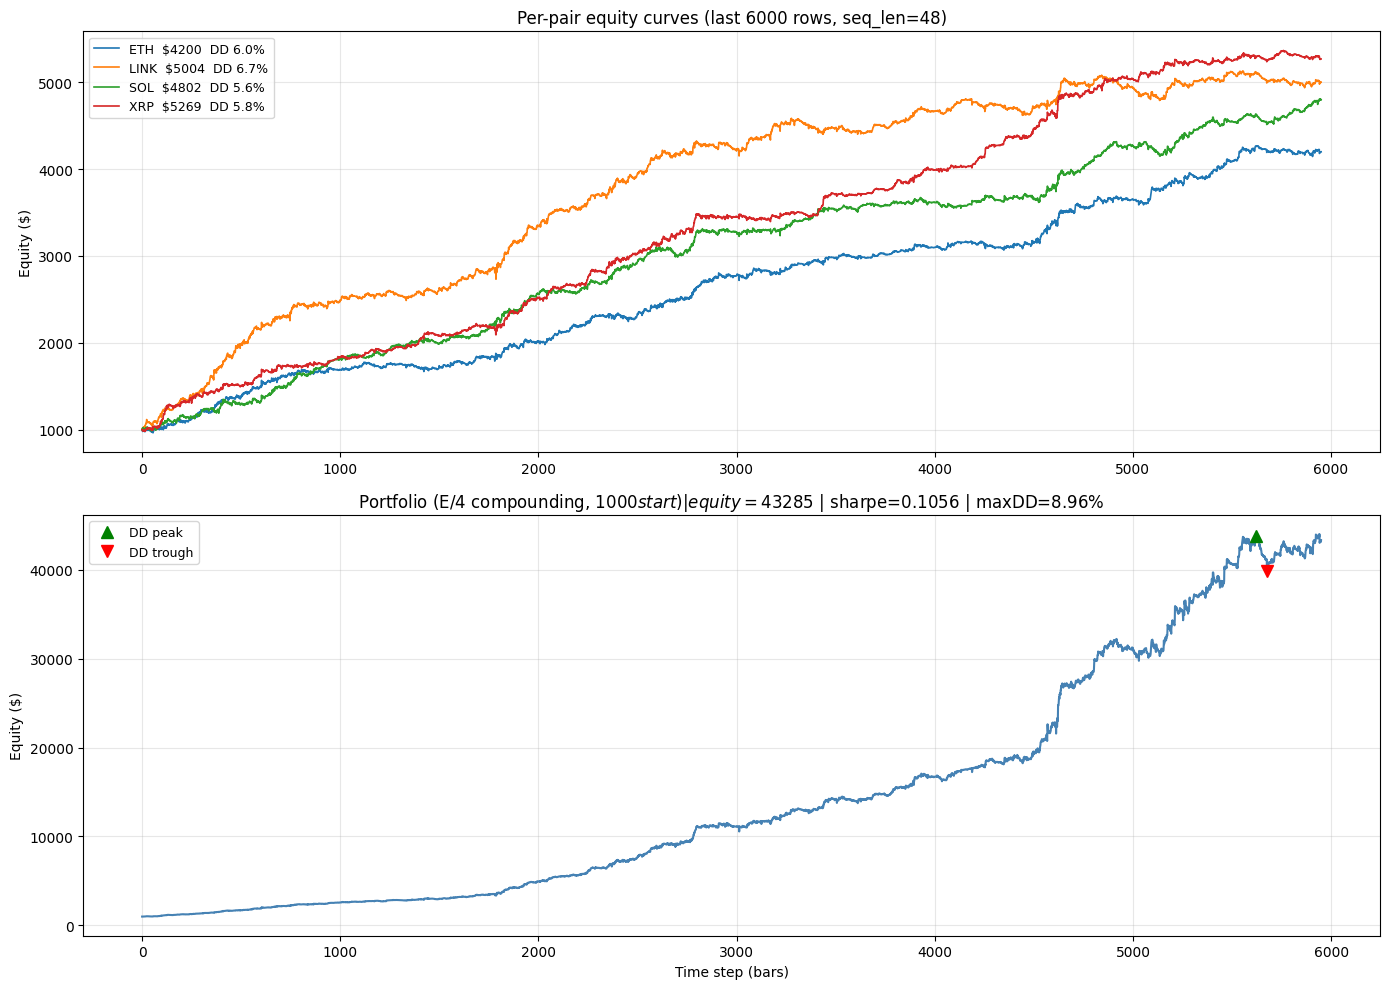

In [47]:
# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Top: per-pair equity curves ---
ax_pairs = axes[0]
for r in results:
    eq = r["equities"][:min_len]
    ax_pairs.plot(eq, lw=1.2, label=f"{r['name']}  ${eq[-1]:.0f}  DD {r['maxdd']['max_drawdown']:.1%}")
ax_pairs.set_title(f"Per-pair equity curves (last {TAIL_ROWS} rows, seq_len={SEQ_LEN})")
ax_pairs.set_ylabel("Equity ($)")
ax_pairs.legend(loc="upper left", fontsize=9)
ax_pairs.grid(True, alpha=0.3)

# --- Bottom: portfolio equity curve ---
ax_port = axes[1]
ax_port.plot(portfolio_equity, lw=1.5, color="steelblue")
ax_port.set_title(
    f"Portfolio (E/4 compounding, ${PORTFOLIO_INITIAL:g} start) | equity=${portfolio_equity[-1]:.0f} "
    f"| sharpe={p_sh:.4f} | maxDD={p_dd['max_drawdown']:.2%}"
)
ax_port.set_xlabel("Time step (bars)")
ax_port.set_ylabel("Equity ($)")
ax_port.grid(True, alpha=0.3)

# Mark max-drawdown on portfolio
peak_i   = p_dd["peak_index"]
trough_i = p_dd["trough_index"]
ax_port.plot(peak_i,   portfolio_equity[peak_i],   "g^", ms=8, label="DD peak")
ax_port.plot(trough_i, portfolio_equity[trough_i], "rv", ms=8, label="DD trough")
ax_port.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

